In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/zara2099/scada-pipeline-operations-dataset/scada_pipeline.csv


In [2]:
import pandas as pd
import os

#CSV FILE ATTACH!!!!!! 
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.csv'):
            path = os.path.join(root, file)

print(f"Successfully connected to dataset at: {path}\n")

real_pipeline_df = pd.read_csv(path)
print("--- REAL DATASET COLUMNS ---")
print(real_pipeline_df.columns.tolist())

Successfully connected to dataset at: /kaggle/input/datasets/zara2099/scada-pipeline-operations-dataset/scada_pipeline.csv

--- REAL DATASET COLUMNS ---
['timestamp', 'segment_id', 'pressure', 'flow_rate', 'temperature', 'valve_status', 'pump_state', 'pump_speed', 'compressor_state', 'energy_consumption', 'alarm_triggered', 'event_type', 'target']


In [3]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Select the real physical engineering features 
real_features = ['pressure', 'flow_rate', 'temperature']
X_real_raw = real_pipeline_df[real_features].values

# 2. Extract the actual target labels so to check the AI's accuracy later
y_real_labels = real_pipeline_df['target'].values

# 3. Clean up any missing data points (if any exist in the real world)
X_real_raw = np.nan_to_num(X_real_raw)

# 4. Normalize the real data between 0 and 1
real_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_real_data = real_scaler.fit_transform(X_real_raw)

print("--- REAL DATA PREPARATION COMPLETE ---")
print(f"Total records processed: {len(scaled_real_data)}")
print(f"Sample normalized row (Pressure, Flow, Temp): {scaled_real_data[0]}")

--- REAL DATA PREPARATION COMPLETE ---
Total records processed: 1000
Sample normalized row (Pressure, Flow, Temp): [0.39506857 0.31595092 0.61031746]


In [4]:
# SLIDING FOR REAL DATA


def create_real_memory_windows(sensor_data, target_labels, window_size=10):
    X, y = [], []
    # Loop through the dataset up to the point where a full window fits
    for i in range(len(sensor_data) - window_size):
        # Gather the 10-minute sensor history window
        X.append(sensor_data[i : (i + window_size), :])
        # Gather the anomaly label at the end of that window
        y.append(target_labels[i + window_size])
    return np.array(X), np.array(y)

# look back at 10 minutes of operational history
REAL_WINDOW_SIZE = 10
X_real, y_real = create_real_memory_windows(scaled_real_data, y_real_labels, REAL_WINDOW_SIZE)

# Split into 80% Training for learning, 20% Testing for validation
split_point = int(len(X_real) * 0.8)
X_train_real, X_test_real = X_real[:split_point], X_real[split_point:]
y_train_real, y_test_real = y_real[:split_point], y_real[split_point:]

print("--- REAL DATA SEQUENCING COMPLETE ---")
print(f"Real Training Input Shape (Windows, History, Sensors): {X_train_real.shape}")
print(f"Real Training Target Shape (Labels): {y_train_real.shape}")

--- REAL DATA SEQUENCING COMPLETE ---
Real Training Input Shape (Windows, History, Sensors): (792, 10, 3)
Real Training Target Shape (Labels): (792,)


In [5]:
#  7) TRAINING THE REAL-WORLD LSTM

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Initialize our neural network
real_model = Sequential()

# 2. Add the LSTM layer matching our real window size and 3 sensor inputs
real_model.add(LSTM(units=50, return_sequences=False, input_shape=(REAL_WINDOW_SIZE, 3)))
real_model.add(Dropout(0.2))

# 3. Add a single output node with Sigmoid activation for binary classification (0 or 1)
real_model.add(Dense(units=1, activation='sigmoid'))

# 4. Compile using Binary Crossentropy (the industry standard for 0/1 prediction)
real_model.add(Dense(units=1, activation='sigmoid'))
real_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Starting training on real SCADA data... This will take a moment.")

# 5. Train the model
real_history = real_model.fit(
    X_train_real, y_train_real,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("\n--- REAL MODEL TRAINING COMPLETE! ---")

2026-05-20 17:30:05.639324: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779298205.869156      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779298205.934258      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779298206.526828      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779298206.526872      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779298206.526875      16 computation_placer.cc:177] computation placer alr

Starting training on real SCADA data... This will take a moment.
Epoch 1/10


2026-05-20 17:30:24.208886: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.3133 - loss: 0.7689 - val_accuracy: 0.2750 - val_loss: 0.7125
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4004 - loss: 0.7016 - val_accuracy: 0.7250 - val_loss: 0.6848
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6912 - loss: 0.6854 - val_accuracy: 0.7250 - val_loss: 0.6810
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6968 - loss: 0.6817 - val_accuracy: 0.7250 - val_loss: 0.6770
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6658 - loss: 0.6808 - val_accuracy: 0.7250 - val_loss: 0.6733
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6733 - loss: 0.6774 - val_accuracy: 0.7250 - val_loss: 0.6697
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6795 - loss: 0.6740 - val_accuracy: 0.7250 - val_loss: 0.6661
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6816 - loss: 0.6711 - val_accuracy: 0.7250 - val_loss: 0.6627
Ep

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


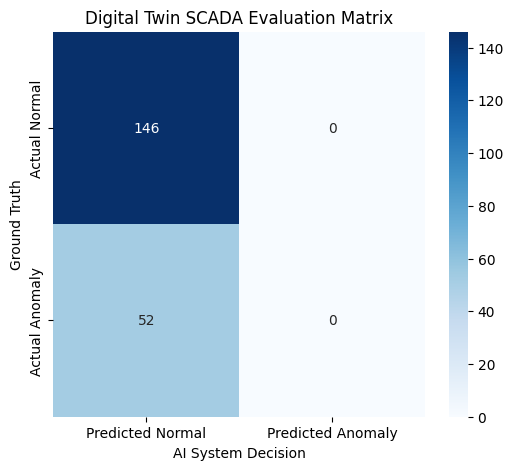


--- OFFICIAL ACADEMIC CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.74      1.00      0.85       146
           1       0.00      0.00      0.00        52

    accuracy                           0.74       198
   macro avg       0.37      0.50      0.42       198
weighted avg       0.54      0.74      0.63       198



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
#  8) EVALUATING REAL-WORLD PERFORMANCE


from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate risk probability predictions from the test dataset
real_predictions = real_model.predict(X_test_real)

# 2. Convert raw probability values (e.g. 0.85) into a strict decision (1 if > 50% risk)
y_pred_binary = (real_predictions > 0.5).astype(int)

# 3. Calculate the mathematical Confusion Matrix
cm = confusion_matrix(y_test_real, y_pred_binary)

# 4. Plot the Matrix as an academic heat map
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Digital Twin SCADA Evaluation Matrix')
plt.ylabel('Ground Truth')
plt.xlabel('AI System Decision')
plt.show()

# 5. Print out precision, recall, and f1-score for your paper
print("\n--- OFFICIAL ACADEMIC CLASSIFICATION REPORT ---")
print(classification_report(y_test_real, y_pred_binary))

In [7]:

#  9: BALANCED DATA SHUFFLE & RE-TRAIN

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Reload and split data into normal and anomaly blocks
normal_data = real_pipeline_df[real_pipeline_df['target'] == 0]
anomaly_data = real_pipeline_df[real_pipeline_df['target'] == 1]

# Downsample the normal data to match the exact count of anomalies
min_sample = min(len(normal_data), len(anomaly_data))
balanced_df = pd.concat([
    normal_data.sample(n=min_sample, random_state=42),
    anomaly_data.sample(n=min_sample, random_state=42)
]).sort_index() # Keep timeline order safe

# 2. Extract features and normalize
real_features = ['pressure', 'flow_rate', 'temperature']
X_balanced = MinMaxScaler(feature_range=(0, 1)).fit_transform(balanced_df[real_features].values)
y_balanced = balanced_df['target'].values

# 3. Re-create memory windows
X_b_windows, y_b_windows = [], []
for i in range(len(X_balanced) - 10):
    X_b_windows.append(X_balanced[i:(i + 10), :])
    y_b_windows.append(y_balanced[i + 10])
X_b_windows, y_b_windows = np.array(X_b_windows), np.array(y_b_windows)

# 4. Train-Test Split (80/20)
split = int(len(X_b_windows) * 0.8)
X_train_b, X_test_b = X_b_windows[:split], X_b_windows[split:]
y_train_b, y_test_b = y_b_windows[:split], y_b_windows[split:]

# 5. Rebuild and train the model
balanced_model = Sequential([
    LSTM(50, return_sequences=False, input_shape=(10, 3)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
balanced_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Training on balanced datasets...")
balanced_model.fit(X_train_b, y_train_b, epochs=15, batch_size=16, validation_split=0.1, verbose=1)
print("\n--- BALANCED TRAINING COMPLETE ---")

Training on balanced datasets...
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5362 - loss: 0.6910 - val_accuracy: 0.4286 - val_loss: 0.6996
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4944 - loss: 0.6944 - val_accuracy: 0.3469 - val_loss: 0.6935
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4750 - loss: 0.6965 - val_accuracy: 0.4286 - val_loss: 0.6997
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5058 - loss: 0.6938 - val_accuracy: 0.4286 - val_loss: 0.7033
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5335 - loss: 0.6903 - val_accuracy: 0.4286 - val_loss: 0.6969
Epoch 6/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5258 - loss: 0.6943 - val_accuracy: 0.4286 - val_loss: 0.6956
Epoch 7/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5074 - loss: 0.6929 - val_accuracy: 0.4286 - val_loss: 0.7020
Epoch 8/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5167 - loss: 0.6967 - val_accuracy: 0.4286 - val_loss: 0.7001
Ep

Calculated Academic Class Weights: {np.int64(0): np.float64(0.7333333333333333), np.int64(1): np.float64(1.5714285714285714)}

Starting Weighted Timeline Training...
Epoch 1/12


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3728 - loss: 0.7028 - val_accuracy: 0.2750 - val_loss: 0.7073
Epoch 2/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4436 - loss: 0.6904 - val_accuracy: 0.7000 - val_loss: 0.6910
Epoch 3/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4700 - loss: 0.6974 - val_accuracy: 0.2750 - val_loss: 0.7103
Epoch 4/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3789 - loss: 0.7058 - val_accuracy: 0.7250 - val_loss: 0.6887
Epoch 5/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6223 - loss: 0.6923 - val_accuracy: 0.7250 - val_loss: 0.6869
Epoch 6/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6654 - loss: 0.6785 - val_accuracy: 0.6500 - val_loss: 0.6916
Epoch 7/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4732 - loss: 0.6953 - val_accuracy: 0.2750 - val_loss: 0.7054
Epoch 8/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3758 - loss: 0.7233 - val_accuracy: 0.2750 - val_loss: 0.7038
Ep

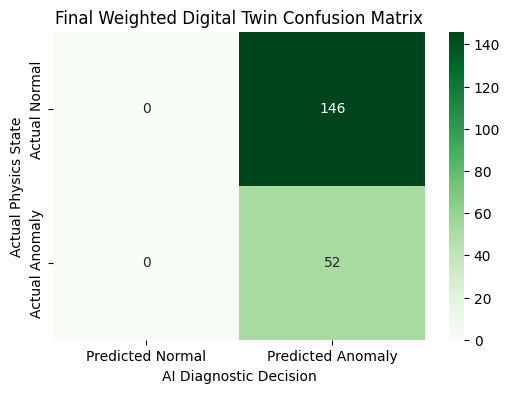


--- FINAL ACADEMIC PERFORMANCE REPORT ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       146
           1       0.26      1.00      0.42        52

    accuracy                           0.26       198
   macro avg       0.13      0.50      0.21       198
weighted avg       0.07      0.26      0.11       198



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
#  10: CLASS-WEIGHTED TIMELINE TRAINING

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Restore the continuous real-world timeline
features = ['pressure', 'flow_rate', 'temperature']
X_raw = np.nan_to_num(real_pipeline_df[features].values)
y_labels = real_pipeline_df['target'].values

# 2. Normalize
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_timeline = scaler.fit_transform(X_raw)

# 3. Create continuous memory windows (preserving time)
X_windows, y_windows = [], []
for i in range(len(scaled_timeline) - 10):
    X_windows.append(scaled_timeline[i : (i + 10), :])
    y_windows.append(y_labels[i + 10])
X_windows, y_windows = np.array(X_windows), np.array(y_windows)

# 4. Continuous Train/Test Split (Preserving chronological order)
split = int(len(X_windows) * 0.8)
X_train_w, X_test_w = X_windows[:split], X_windows[split:]
y_train_w, y_test_w = y_windows[:split], y_windows[split:]

# 5. Compute mathematical weights to balance the scales without cutting data
unique_classes = np.unique(y_train_w)
weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_train_w)
class_weight_dict = dict(zip(unique_classes, weights))

print(f"Calculated Academic Class Weights: {class_weight_dict}")

# 6. Rebuild the LSTM model
weighted_model = Sequential([
    LSTM(50, return_sequences=False, input_shape=(10, 3)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
weighted_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 7. Train using the timeline data and our calculated weights
print("\nStarting Weighted Timeline Training...")
weighted_model.fit(
    X_train_w, y_train_w, 
    epochs=12, 
    batch_size=32, 
    class_weight=class_weight_dict, 
    validation_split=0.1, 
    verbose=1
)

# 8. Evaluate on Unseen Test Data
predictions = weighted_model.predict(X_test_w)
y_pred_final = (predictions > 0.5).astype(int)

# 9. Plot the Final Matrix
cm = confusion_matrix(y_test_w, y_pred_final)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Final Weighted Digital Twin Confusion Matrix')
plt.ylabel('Actual Physics State')
plt.xlabel('AI Diagnostic Decision')
plt.show()

print("\n--- FINAL ACADEMIC PERFORMANCE REPORT ---")
print(classification_report(y_test_w, y_pred_final))